In [1]:
import sys
import numpy as np
import cv2
from matplotlib import pyplot as plt
sys.path.append('../robot')
from common import arena

In [2]:
low_probability = 10 ** -10
# Ranges for world x and y coordinates, indexed by map coordinates
map_frame = arena.MapFrame(100)

In [23]:
def plot_map(map_data):
    plt.figure(figsize=(8, 8))
    plt.imshow(
        map_data,
        cmap='gray_r',
        origin='lower',
        extent=[map_frame.w_left, map_frame.w_right, map_frame.w_bottom, map_frame.w_top]
    )

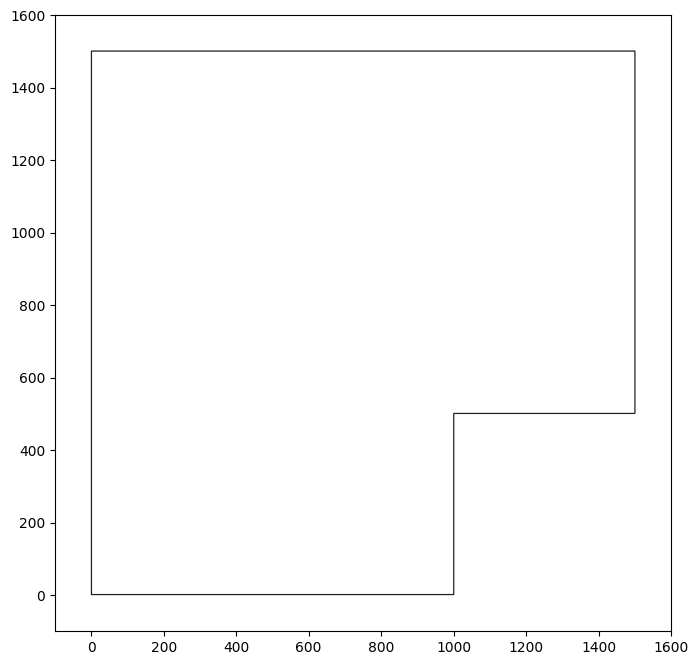

In [26]:
walls_map = np.zeros((map_frame.height, map_frame.width), dtype=np.float32)
cv2.polylines(walls_map, 
              map_frame.world_to_map(np.array([arena.walls])), 
              isClosed=True, color=1.0, thickness=2)

plot_map(walls_map)

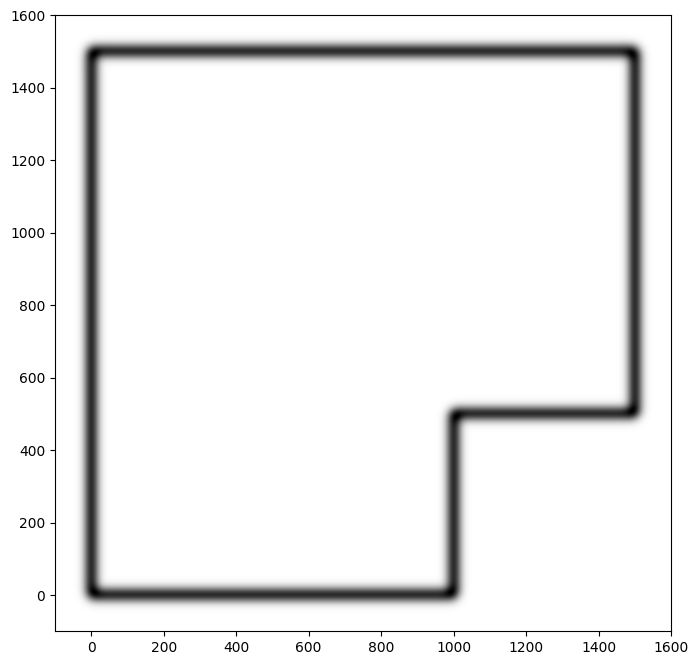

In [58]:
distance_map = cv2.GaussianBlur(walls_map, (0, 0), 15)
plot_map(distance_map)

Text(0.5, 1.0, 'Distance values along y = 200')

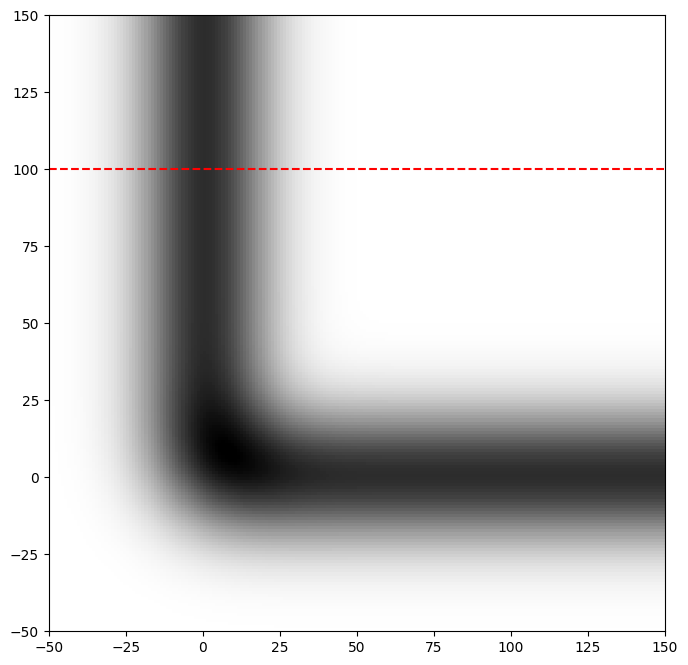

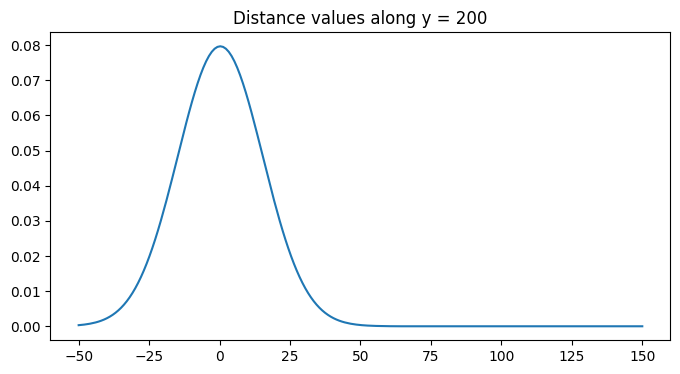

In [77]:
plot_map(distance_map)
axs = plt.gca()
axs.set_xlim(-50, 150)
axs.set_ylim(-50, 150)
# Draw a line at y = 150
plt.axhline(y=100, color='r', linestyle='--')
# # Draw a further plot of the row y = 100
map_y = 100 + map_frame.margin
row = distance_map[map_y, 50:250]
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(-50, 150, 200), row)
plt.title(f'Distance values along y = {map_y}')

In [82]:
np.min(distance_map), np.max(distance_map)

(np.float32(0.0), np.float32(0.09661646))

(np.float32(1e-10), np.float32(1.0))

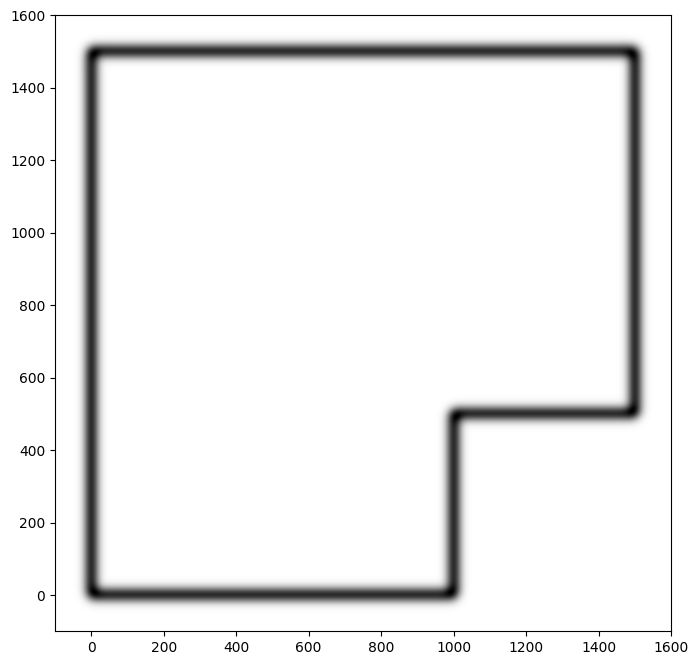

In [87]:
normalized_map = cv2.normalize(distance_map, None, alpha=low_probability, beta=1.0, norm_type=cv2.NORM_MINMAX)
plot_map(normalized_map)
np.min(normalized_map), np.max(normalized_map)

In [88]:
np.save('../robot/observation_models/distance_map.npy', normalized_map)